In [1]:
import pandas as pd
df = pd.read_csv('../data/retail_sales_dataset.csv')

df.shape


(1000, 9)

In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [3]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
df.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


Total Amount has a std of 560 vs a mean of 456 — a ratio of 1.23 (123%), which is very high. This means spending is highly variable and unpredictable: typical purchases are ~135, but values range from 25 to 2000. Spending is NOT consistent.

In [5]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [6]:
count = df['Gender'].value_counts()
percentage = df['Gender'].value_counts(normalize=True)*100

summary = pd.DataFrame({
    'Count': count,
    'Percentage':percentage
})

print(summary)

        Count  Percentage
Gender                   
Female    510        51.0
Male      490        49.0


In [7]:
counts = df['Product Category'].value_counts()
percentages  = df['Product Category'].value_counts(normalize = True) * 100

summary = pd.DataFrame({
    'Count': counts,
    'Percentage' : percentages
})

print(summary)

                  Count  Percentage
Product Category                   
Clothing            351        35.1
Electronics         342        34.2
Beauty              307        30.7


### 1. Sales Over Time (Monthly Trend)
Converting Date from text to a real datetime, then summing Total Amount per month to see seasonal patterns.

In [8]:
df['Date'] = pd.to_datetime(df['Date'])
monthly_sales = df.groupby(df['Date'].dt.month)['Total Amount'].sum()
monthly_sales

Date
1     36980
2     44060
3     28990
4     33870
5     53150
6     36715
7     35465
8     36960
9     23620
10    46580
11    34920
12    44690
Name: Total Amount, dtype: int64

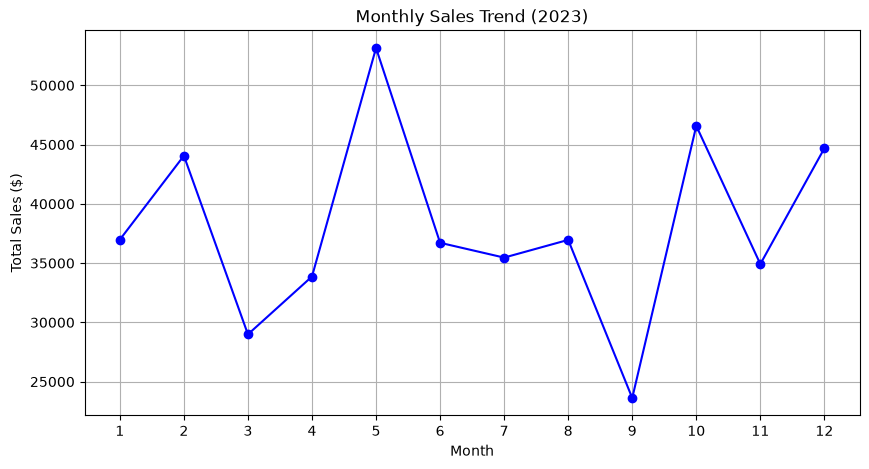

In [9]:
# Monthly sales trend line plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
monthly_sales.plot(kind='line', marker='o', color='b', linestyle='-')
plt.title('Monthly Sales Trend (2023)')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.grid(True)
plt.xticks(range(1, 13))
plt.show()

### 2. Age Distribution
A histogram with 20 bins shows how customers are spread across ages.

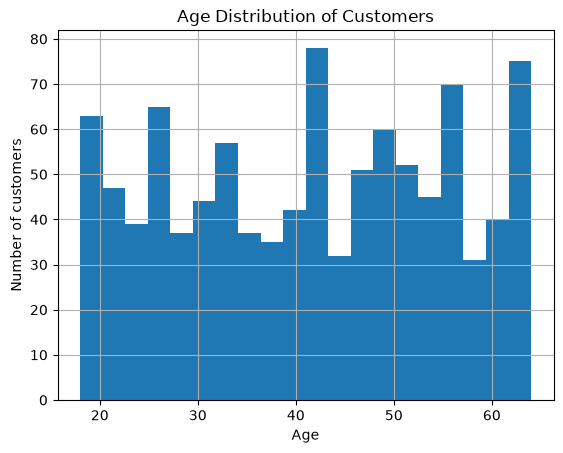

In [10]:
import matplotlib.pyplot as plt
df['Age'].hist(bins=20)
plt.xlabel('Age')
plt.ylabel('Number of customers')
plt.title('Age Distribution of Customers')
plt.show()

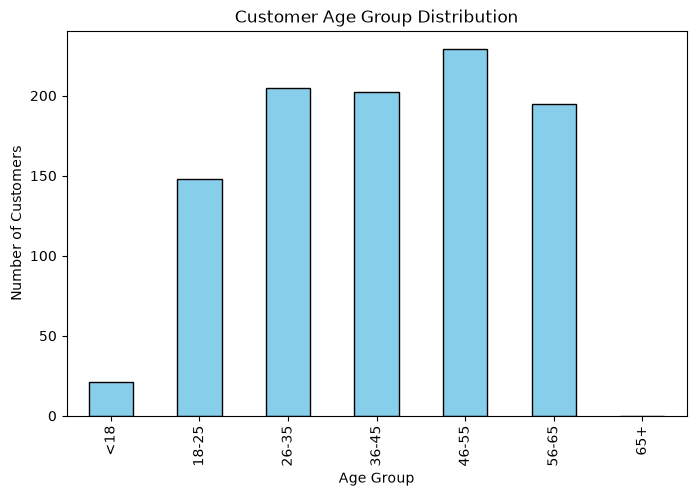

In [11]:
# Bin age values into brackets
age_bins = [0, 18, 25, 35, 45, 55, 65, 100]
age_labels = ['<18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df['Age Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

# Plot age groups
plt.figure(figsize=(8, 5))
df['Age Group'].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Customer Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.show()

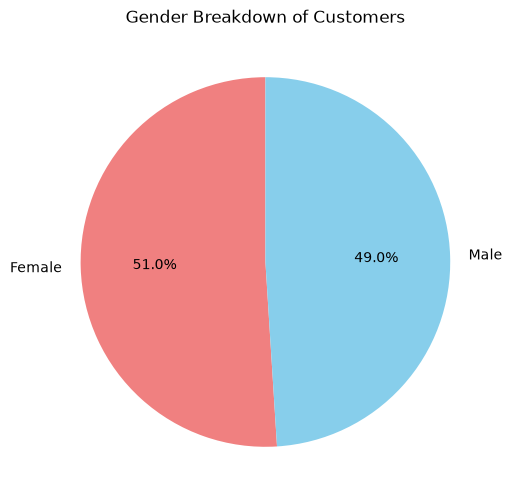

In [12]:
# Gender distribution pie chart
plt.figure(figsize=(6, 6))
df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['lightcoral', 'skyblue'], startangle=90)
plt.title('Gender Breakdown of Customers')
plt.ylabel('')
plt.show()

### 3. Correlation Heatmap
How strongly do the numeric columns move together? (1 = perfect match, 0 = no link, -1 = opposite).

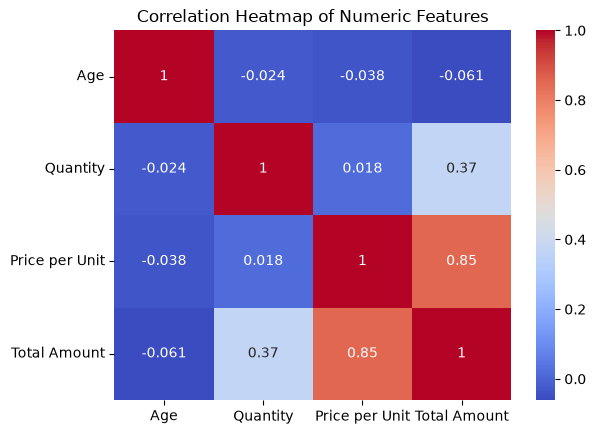

In [13]:
import seaborn as sns
numeric_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

<Figure size 1000x600 with 0 Axes>

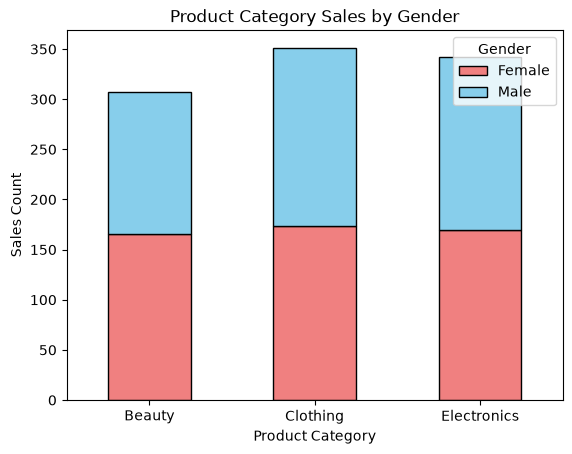

In [14]:
# Stacked bar chart: Gender vs Product Category
plt.figure(figsize=(10, 6))
gender_category = pd.crosstab(df['Product Category'], df['Gender'])
gender_category.plot(kind='bar', stacked=True, color=['lightcoral', 'skyblue'], edgecolor='black')
plt.title('Product Category Sales by Gender')
plt.ylabel('Sales Count')
plt.xlabel('Product Category')
plt.legend(title='Gender')
plt.xticks(rotation=0)
plt.show()

### 4. Revenue by Category
Which category generates the most total revenue?

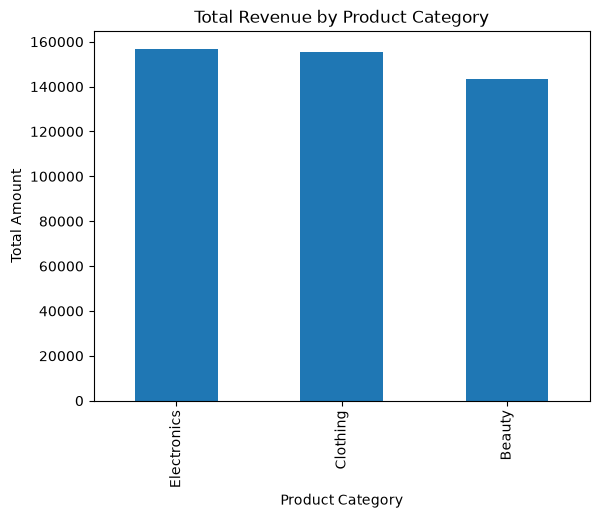

In [15]:
category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
category_revenue.plot(kind='bar')
plt.title('Total Revenue by Product Category')
plt.ylabel('Total Amount')
plt.show()

In [16]:
# Get the mode for numerical and category columns
print("Mode for Age:", df['Age'].mode()[0])
print("Mode for Product Category:", df['Product Category'].mode()[0])
print("Mode for Quantity:", df['Quantity'].mode()[0])
print("Mode for Price per Unit:", df['Price per Unit'].mode()[0])
print("Mode for Total Amount:", df['Total Amount'].mode()[0])

Mode for Age: 43
Mode for Product Category: Clothing
Mode for Quantity: 4
Mode for Price per Unit: 50
Mode for Total Amount: 50


### Conclusion & Insights
Here are 3 key takeaways from the analysis of the dataset:

1. **Balanced Gender Split**: The data shows an almost equal 51% to 49% split of female and male customers across all categories. Marketing campaigns shouldn't target one gender over another.
2. **Sales Drop in September**: Revenue peaks in May and October, but drops significantly in September. To stabilize monthly income, the store should run special discounts or product bundles in September.
3. **Age Doesn't Affect Spending**: The correlation heatmap shows near-zero correlation between Age and purchase quantities/amounts. This means age is not a major factor in buying behavior, so marketing should focus on product types rather than age demographics.